<a href="https://colab.research.google.com/github/leticiasdrummond/Modelos-Base/blob/main/Economia_de_Energia_EVE_Usinas_GN_e_PV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**FEM/Unicamp**

---



PE 102 – ECONOMIA DE ENERGIA II

Avaliação individual II








10 de junho de 2026


# **2nda Atividade**
**Atividade Intividual de Economia de Energia II**

- Letícia Sampaio Drummond Valladares RA:298985
- Professor: Arnaldo Walter

Junho de 2026

---

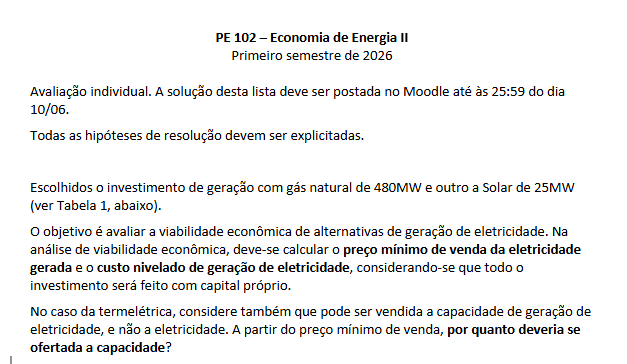

## Economia de Energia - AVE Usinas GN e PV

- AVE - Avaliação de Viabilidade Economomica
- GN - GÁS Natural 480MW
- FV - Usina Fotovoltaica 25MW

In [ ]:
# @title **Valore Pré-Estabelecidos** e escolhidos também
import pandas as pd

# --- Parâmetros Comuns ---
discount_rate = 0.08  # 8% escolhido como uma taxa razoável para investimentos privados em energia
hours_per_year = 8760

# --- Parâmetros da Usina a Gás Natural ---
capacity_gas_mw = 480  # MW
overnight_costs_gas_usd_per_kw = 739  # US$/kW
efficiency_gas_percent = 0.34  # 34% (eficiência elétrica)
o_m_gas_usd_per_mwh = 16.71  # US$/MWh
capacity_factor_gas_percent = 0.30  # 30% (interpretado como fator de capacidade anual)
fuel_cost_gas_usd_per_gj = 5.0  # US$/GJ
construction_time_gas_years = 3  # Anos
operational_life_gas_years = 30  # Anos

# Frações do custo de construção para Gás Natural (anos antes do início da operação: -2, -1, 0)
construction_fractions_gas = {
    'Ano -2': 0.17,
    'Ano -1': 0.49,
    'Ano 0': 0.34  # Ano de comissionamento / início da operação
}

# --- Parâmetros da Usina Solar ---
capacity_solar_mw = 25  # MW
overnight_costs_solar_usd_per_kw = 1197  # US$/kW
o_m_solar_usd_per_mwh = 6.48  # US$/MWh
capacity_factor_solar_percent = 0.31  # 31% (interpretado como fator de capacidade anual)
construction_time_solar_years = 2  # Anos
operational_life_solar_years = 25  # Anos

# Frações do custo de construção para Solar (anos antes do início da operação: -1, 0)
construction_fractions_solar = {
    'Ano -1': 0.40,
    'Ano 0': 0.60  # Ano de comissionamento / início da operação
}

# --- Parâmetros de Impostos e Encargos ---
tax_confins = 0.0760  # 7,60% sobre a receita bruta
tax_pis = 0.0165  # 1,65% sobre a receita bruta
tax_tfsee = 0.0050  # 0,50% sobre a receita bruta
tax_csll = 0.090  # 9,0% sobre o lucro real
tax_ir_base = 0.150  # 15,0% sobre o lucro real
tax_ir_additional = 0.100  # 10,0% adicional sobre o lucro que exceder o limite
ir_profit_threshold_monthly_usd = 3508.59  # Valor de referência EPE para o Dólar e 200mil da regra

print("Parâmetros definidos com sucesso.")

In [ ]:
import pandas as pd
import numpy as np
from scipy.optimize import fsolve

# =====================================================
# 1. PARÂMETROS DEFINIDOS
# =====================================================

# --- Parâmetros Comuns ---
taxa_desconto = 0.08  # 8% escolhido como uma taxa razoável para investimentos privados em energia
horas_por_ano = 8760

# --- Parâmetros da Usina a Gás Natural ---
capacidade_gas_mw = 480  # MW
custo_instantaneo_gas_usd_por_kw = 739  # US$/kW
eficiencia_gas_percentual = 0.34  # 34% (eficiência elétrica)
custo_om_gas_usd_por_mwh = 16.71  # US$/MWh
fator_capacidade_gas_percentual = 0.30  # 30% (fator de capacidade anual)
custo_combustivel_gas_usd_por_gj = 5.0  # US$/GJ
tempo_construcao_gas_anos = 3  # Anos
vida_operacional_gas_anos = 30  # Anos

# Frações do custo de construção para Gás Natural (anos antes do início da operação: -2, -1, 0)
fracoes_construcao_gas = {
    'Ano -2': 0.17,
    'Ano -1': 0.49,
    'Ano 0': 0.34  # Ano de comissionamento / início da operação
}

# --- Parâmetros da Usina Solar ---
capacidade_solar_mw = 25  # MW
custo_instantaneo_solar_usd_por_kw = 1197  # US$/kW
custo_om_solar_usd_por_mwh = 6.48  # US$/MWh
fator_capacidade_solar_percentual = 0.31  # 31% (fator de capacidade anual)
tempo_construcao_solar_anos = 2  # Anos
vida_operacional_solar_anos = 25  # Anos

# Frações do custo de construção para Solar (anos antes do início da operação: -1, 0)
fracoes_construcao_solar = {
    'Ano -1': 0.40,
    'Ano 0': 0.60  # Ano de comissionamento / início da operação
}

# --- Parâmetros de Impostos e Encargos (Comuns para ambos) ---
aliquota_confins = 0.0760  # 7,60% sobre a receita bruta
aliquota_pis = 0.0165  # 1,65% sobre a receita bruta
aliquota_tfsee = 0.0050  # 0,50% sobre a receita bruta
aliquota_csll = 0.090  # 9,0% sobre o lucro real
aliquota_ir_base = 0.150  # 15,0% sobre o lucro real
aliquota_ir_adicional = 0.100  # 10,0% adicional sobre o lucro que exceder o limite
limite_mensal_ir_usd = 3508.59  # Valor do Dólar pela EPE 2017b para o limite do IR em reais

print("=" * 70)
print("PARÂMETROS DEFINIDOS COM SUCESSO")
print("=" * 70)
print(f"Taxa de Desconto: {taxa_desconto * 100:.1f}%")
print(f"Horas por Ano: {horas_por_ano}")
print()

# =====================================================
# 2. CUSTOS OVERNIGHT TOTAIS
# =====================================================

print("=" * 70)
print("CUSTOS OVERNIGHT TOTAIS")
print("=" * 70)

# Custos Overnight Totais
custo_instantaneo_total_gas = capacidade_gas_mw * 1000 * custo_instantaneo_gas_usd_por_kw
custo_instantaneo_total_solar = capacidade_solar_mw * 1000 * custo_instantaneo_solar_usd_por_kw

print(f"Usina a Gás Natural: US$ {custo_instantaneo_total_gas:,.2f}")
print(f"Usina Solar: US$ {custo_instantaneo_total_solar:,.2f}")
print()

# =====================================================
# 3. CUSTO TOTAL DE INVESTIMENTO COM FINANCIAMENTO
# =====================================================

print("=" * 70)
print("CUSTO TOTAL DE INVESTIMENTO (COM FINANCIAMENTO DURANTE A CONSTRUÇÃO)")
print("=" * 70)

# Cálculo do custo total de investimento incluindo financiamento durante a construção
valor_presente_construcao_gas = 0
for ano_str, fracao in fracoes_construcao_gas.items():
    deslocamento_ano = int(ano_str.split(' ')[1])
    anos_para_capitalizar = -deslocamento_ano
    valor_presente_construcao_gas += custo_instantaneo_total_gas * fracao * ((1 + taxa_desconto)**anos_para_capitalizar)

valor_presente_construcao_solar = 0
for ano_str, fracao in fracoes_construcao_solar.items():
    deslocamento_ano = int(ano_str.split(' ')[1])
    anos_para_capitalizar = -deslocamento_ano
    valor_presente_construcao_solar += custo_instantaneo_total_solar * fracao * ((1 + taxa_desconto)**anos_para_capitalizar)

custo_investimento_total_gas = valor_presente_construcao_gas
custo_investimento_total_solar = valor_presente_construcao_solar

print(f"Usina a Gás Natural (no COD): US$ {custo_investimento_total_gas:,.2f}")
print(f"Usina Solar (no COD): US$ {custo_investimento_total_solar:,.2f}")
print()

# =====================================================
# 4. GERAÇÃO ANUAL DE ELETRICIDADE
# =====================================================

print("=" * 70)
print("GERAÇÃO ANUAL DE ELETRICIDADE")
print("=" * 70)

# Geração anual (MWh) = Capacidade (MW) * Fator de Capacidade * Horas por Ano
geracao_anual_gas_mwh = capacidade_gas_mw * fator_capacidade_gas_percentual * horas_por_ano
geracao_anual_solar_mwh = capacidade_solar_mw * fator_capacidade_solar_percentual * horas_por_ano

print(f"Usina a Gás Natural: {geracao_anual_gas_mwh:,.2f} MWh")
print(f"Usina Solar: {geracao_anual_solar_mwh:,.2f} MWh")
print()

# =====================================================
# 5. CUSTOS ANUAIS DE O&M
# =====================================================

print("=" * 70)
print("CUSTOS ANUAIS DE OPERAÇÃO E MANUTENÇÃO (O&M)")
print("=" * 70)

# O&M anual (USD) = O&M por MWh * Geração Anual (MWh)
custo_om_anual_gas_usd = custo_om_gas_usd_por_mwh * geracao_anual_gas_mwh
custo_om_anual_solar_usd = custo_om_solar_usd_por_mwh * geracao_anual_solar_mwh

print(f"Usina a Gás Natural: US$ {custo_om_anual_gas_usd:,.2f}")
print(f"Usina Solar: US$ {custo_om_anual_solar_usd:,.2f}")
print()

# =====================================================
# 6. CUSTOS ANUAIS DE COMBUSTÍVEL (GÁS NATURAL)
# =====================================================

print("=" * 70)
print("CUSTOS ANUAIS DE COMBUSTÍVEL (APENAS GÁS NATURAL)")
print("=" * 70)

# Converter MWh para GJ para cálculo do combustível (1 MWh = 3,6 GJ)
geracao_anual_gas_gj = geracao_anual_gas_mwh * 3.6

# Combustível necessário em GJ, considerando a eficiência
combustivel_necessario_gas_gj = geracao_anual_gas_gj / eficiencia_gas_percentual

# Custo Anual de Combustível
custo_combustivel_anual_gas_usd = combustivel_necessario_gas_gj * custo_combustivel_gas_usd_por_gj

print(f"Usina a Gás Natural: US$ {custo_combustivel_anual_gas_usd:,.2f}")
print(f"Usina Solar: US$ 0,00 (não possui custo de combustível)")
print()

# =====================================================
# 7. CÁLCULO DO LCOE (CUSTO NIVELADO DE ELETRICIDADE)
# =====================================================

print("=" * 70)
print("CUSTO NIVELADO DE ELETRICIDADE (LCOE)")
print("=" * 70)

# Função para calcular o Fator de Valor Presente de uma Anuidade (PVIFA)
def calcular_fator_valor_presente_anuidade(taxa, periodos):
    """Calcula o fator de valor presente de uma série uniforme de pagamentos"""
    if taxa == 0:
        return periodos
    return (1 - (1 + taxa)**(-periodos)) / taxa

# --- LCOE para Usina a Gás Natural ---
fator_anuidade_gas = calcular_fator_valor_presente_anuidade(taxa_desconto, vida_operacional_gas_anos)
valor_presente_opex_gas = (custo_om_anual_gas_usd + custo_combustivel_anual_gas_usd) * fator_anuidade_gas
valor_presente_geracao_gas = geracao_anual_gas_mwh * fator_anuidade_gas
lcoe_gas_usd_por_mwh = (custo_investimento_total_gas + valor_presente_opex_gas) / valor_presente_geracao_gas

print(f"Usina a Gás Natural: US$ {lcoe_gas_usd_por_mwh:,.2f}/MWh")

# --- LCOE para Usina Solar ---
fator_anuidade_solar = calcular_fator_valor_presente_anuidade(taxa_desconto, vida_operacional_solar_anos)
valor_presente_opex_solar = custo_om_anual_solar_usd * fator_anuidade_solar
valor_presente_geracao_solar = geracao_anual_solar_mwh * fator_anuidade_solar
lcoe_solar_usd_por_mwh = (custo_investimento_total_solar + valor_presente_opex_solar) / valor_presente_geracao_solar

print(f"Usina Solar: US$ {lcoe_solar_usd_por_mwh:,.2f}/MWh")
print()

# =====================================================
# 8. PREÇO MÍNIMO DE VENDA DE ELETRICIDADE (PMIN)
# =====================================================

print("=" * 70)
print("PREÇO MÍNIMO DE VENDA DE ELETRICIDADE (PMIN) - COM IMPOSTOS")
print("=" * 70)

# Atualizar a taxa de desconto para este cálculo específico (9%)
taxa_desconto_vpl = 0.09  # 9% ao ano

# --- Calcular Depreciação Anual ---
depreciacao_anual_gas = custo_instantaneo_total_gas / vida_operacional_gas_anos
depreciacao_anual_solar = custo_instantaneo_total_solar / vida_operacional_solar_anos

print(f"Depreciação Anual - Gás Natural: US$ {depreciacao_anual_gas:,.2f}")
print(f"Depreciação Anual - Solar: US$ {depreciacao_anual_solar:,.2f}")

# Combinar as alíquotas de impostos sobre a receita bruta
aliquota_total_impostos_receita = aliquota_confins + aliquota_pis + aliquota_tfsee
print(f"Taxa Total de Impostos sobre Receita Bruta: {aliquota_total_impostos_receita * 100:.2f}%")

# Limite anual para o IR Adicional (mensal * 12)
limite_anual_ir_usd = limite_mensal_ir_usd * 12
print(f"Limite Anual para IR Adicional: US$ {limite_anual_ir_usd:,.2f}")
print()

def calcular_vpl_para_preco(preco_por_mwh, tipo_usina):
    """Calcula o Valor Presente Líquido para um dado preço de venda de eletricidade"""

    # Recuperar parâmetros específicos de cada usina
    if tipo_usina == 'gas':
        investimento_total = custo_investimento_total_gas
        geracao_anual_mwh = geracao_anual_gas_mwh
        custo_om_anual_usd = custo_om_anual_gas_usd
        custo_combustivel_anual_usd = custo_combustivel_anual_gas_usd
        vida_util_anos = vida_operacional_gas_anos
        depreciacao = depreciacao_anual_gas
    elif tipo_usina == 'solar':
        investimento_total = custo_investimento_total_solar
        geracao_anual_mwh = geracao_anual_solar_mwh
        custo_om_anual_usd = custo_om_anual_solar_usd
        custo_combustivel_anual_usd = 0  # Solar não tem custos com combustível
        vida_util_anos = vida_operacional_solar_anos
        depreciacao = depreciacao_anual_solar
    else:
        raise ValueError("Tipo de usina inválido. Deve ser 'gas' ou 'solar'.")

    # --- Calcular Componentes do Fluxo de Caixa Anual ---
    receita_bruta = preco_por_mwh * geracao_anual_mwh
    receita_liquida = receita_bruta * (1 - aliquota_total_impostos_receita)
    custos_totais_anuais = custo_om_anual_usd + custo_combustivel_anual_usd

    # Calcular Lucro Real
    lucro_real = receita_liquida - custos_totais_anuais - depreciacao

    # Calcular Impostos sobre o Lucro
    irpj = max(0, aliquota_ir_base * lucro_real)
    csll = max(0, aliquota_csll * lucro_real)
    ir_adicional = max(0, aliquota_ir_adicional * (lucro_real - limite_anual_ir_usd))

    # Calcular Fluxo de Caixa Anual para os anos operacionais
    fluxo_caixa_anual = receita_liquida - custos_totais_anuais - irpj - csll - ir_adicional

    # --- Calcular VPL ---
    vpl = -investimento_total  # Investimento inicial no ano 0 (COD)

    # Somar os fluxos de caixa descontados para os anos operacionais
    for ano in range(1, vida_util_anos + 1):
        vpl += fluxo_caixa_anual / ((1 + taxa_desconto_vpl)**ano)

    return vpl

# --- Encontrar o Preço Mínimo de Venda (P) que torna VPL = 0 ---
# Palpite inicial: um pouco acima do LCOE para cobrir impostos e lucro
palpite_inicial_gas = lcoe_gas_usd_por_mwh * 1.5
palpite_inicial_solar = lcoe_solar_usd_por_mwh * 1.5

# Usar fsolve para encontrar a raiz (preço onde o VPL é zero)
preco_minimo_venda_gas = fsolve(calcular_vpl_para_preco, palpite_inicial_gas, args=('gas',))[0]
preco_minimo_venda_solar = fsolve(calcular_vpl_para_preco, palpite_inicial_solar, args=('solar',))[0]

print(f"Preço Mínimo de Venda - Usina a Gás Natural: US$ {preco_minimo_venda_gas:,.2f}/MWh")
print(f"Preço Mínimo de Venda - Usina Solar: US$ {preco_minimo_venda_solar:,.2f}/MWh")
print()

# =====================================================
# 9. PREÇO MÍNIMO DE VENDA DE CAPACIDADE (GÁS NATURAL)
# =====================================================

print("=" * 70)
print("PREÇO MÍNIMO DE VENDA DE CAPACIDADE (APENAS GÁS NATURAL)")
print("=" * 70)

def calcular_vpl_para_preco_capacidade(preco_capacidade_por_mw_ano):
    """Calcula o VPL para um dado preço de venda de capacidade (MW/ano)"""

    # Parâmetros para a Usina a Gás Natural
    investimento_total = custo_investimento_total_gas
    capacidade_mw = capacidade_gas_mw
    custo_om_anual_usd = custo_om_anual_gas_usd
    custo_combustivel_anual_usd = custo_combustivel_anual_gas_usd
    vida_util_anos = vida_operacional_gas_anos
    depreciacao = depreciacao_anual_gas

    # --- Calcular Componentes do Fluxo de Caixa Anual ---
    receita_bruta = preco_capacidade_por_mw_ano * capacidade_mw
    receita_liquida = receita_bruta * (1 - aliquota_total_impostos_receita)
    custos_totais_anuais = custo_om_anual_usd + custo_combustivel_anual_usd

    # Calcular Lucro Real
    lucro_real = receita_liquida - custos_totais_anuais - depreciacao

    # Calcular Impostos sobre o Lucro
    irpj = max(0, aliquota_ir_base * lucro_real)
    csll = max(0, aliquota_csll * lucro_real)
    ir_adicional = max(0, aliquota_ir_adicional * (lucro_real - limite_anual_ir_usd))

    # Calcular Fluxo de Caixa Anual para os anos operacionais
    fluxo_caixa_anual = receita_liquida - custos_totais_anuais - irpj - csll - ir_adicional

    # --- Calcular VPL ---
    vpl = -investimento_total

    # Somar os fluxos de caixa descontados para os anos operacionais
    for ano in range(1, vida_util_anos + 1):
        vpl += fluxo_caixa_anual / ((1 + taxa_desconto_vpl)**ano)

    return vpl

# Estimar custo operacional anual por MW como palpite inicial
custo_operacional_anual_estimado_por_mw = (custo_om_anual_gas_usd + custo_combustivel_anual_gas_usd) / capacidade_gas_mw
palpite_inicial_preco_capacidade = (custo_operacional_anual_estimado_por_mw +
                                     (custo_investimento_total_gas / vida_operacional_gas_anos / capacidade_gas_mw)) * 2

preco_minimo_venda_capacidade_gas = fsolve(calcular_vpl_para_preco_capacidade, palpite_inicial_preco_capacidade)[0]

print(f"Preço Mínimo de Venda de Capacidade: US$ {preco_minimo_venda_capacidade_gas:,.2f}/MW/ano")
print()

# =====================================================
# 10. RESUMO FINAL
# =====================================================

print("=" * 70)
print("RESUMO FINAL DOS RESULTADOS")
print("=" * 70)
print(f"{'Métrica':<45} {'Gás Natural':>20} {'Solar':>20}")
print("-" * 85)
print(f"{'Capacidade Instalada (MW)':<45} {capacidade_gas_mw:>20,.0f} {capacidade_solar_mw:>20,.0f}")
print(f"{'Fator de Capacidade (%)':<45} {fator_capacidade_gas_percentual*100:>19.1f}% {fator_capacidade_solar_percentual*100:>19.1f}%")
print(f"{'Custo Overnight Total (US$)':<45} {custo_instantaneo_total_gas:>20,.2f} {custo_instantaneo_total_solar:>20,.2f}")
print(f"{'Custo Investimento Total (US$)':<45} {custo_investimento_total_gas:>20,.2f} {custo_investimento_total_solar:>20,.2f}")
print(f"{'Geração Anual (MWh)':<45} {geracao_anual_gas_mwh:>20,.2f} {geracao_anual_solar_mwh:>20,.2f}")
print(f"{'Custo Anual O&M (US$)':<45} {custo_om_anual_gas_usd:>20,.2f} {custo_om_anual_solar_usd:>20,.2f}")
print(f"{'Custo Anual Combustível (US$)':<45} {custo_combustivel_anual_gas_usd:>20,.2f} {'0.00':>20}")
print(f"{'Depreciação Anual (US$)':<45} {depreciacao_anual_gas:>20,.2f} {depreciacao_anual_solar:>20,.2f}")
print(f"{'LCOE - Custo Nivelado (US$/MWh)':<45} {lcoe_gas_usd_por_mwh:>20,.2f} {lcoe_solar_usd_por_mwh:>20,.2f}")
print(f"{'Preço Mínimo de Venda (US$/MWh)':<45} {preco_minimo_venda_gas:>20,.2f} {preco_minimo_venda_solar:>20,.2f}")
print("-" * 85)
print(f"{'Preço Mínimo de Capacidade (US$/MW/ano)':<45} {preco_minimo_venda_capacidade_gas:>41,.2f}")
print("=" * 70)

In [ ]:
import pandas as pd
import numpy as np
from scipy.optimize import fsolve

# =====================================================
# 1. PARÂMETROS DEFINIDOS
# =====================================================

# --- Parâmetros Comuns ---
taxa_desconto = 0.08  # 8% EPE
horas_por_ano = 8760

# --- Parâmetros da Usina a Gás Natural ---
capacidade_gas_mw = 480  # MW
custo_instantaneo_gas_usd_por_kw = 739  # US$/kW
eficiencia_gas_percentual = 0.34  # 34% (eficiência elétrica)
custo_om_gas_usd_por_mwh = 16.71  # US$/MWh
fator_capacidade_gas_percentual = 0.30  # 30% (fator de capacidade anual)
custo_combustivel_gas_usd_por_gj = 5.0  # US$/GJ
tempo_construcao_gas_anos = 3  # Anos
vida_operacional_gas_anos = 30  # Anos

# Frações do custo de construção para Gás Natural (anos antes do início da operação: -2, -1, 0)
# Ano 0 aqui significa o ano de comissionamento, não o final do ano 0.
fracoes_construcao_gas = {
    'Ano -2': 0.17,
    'Ano -1': 0.49,
    'Ano 0': 0.34  # Ano de comissionamento / início da operação
}

# --- Parâmetros da Usina Solar ---
capacidade_solar_mw = 25  # MW
custo_instantaneo_solar_usd_por_kw = 1197  # US$/kW
custo_om_solar_usd_por_mwh = 6.48  # US$/MWh
fator_capacidade_solar_percentual = 0.31  # 31% (fator de capacidade anual)
tempo_construcao_solar_anos = 2  # Anos
vida_operacional_solar_anos = 25  # Anos

# Frações do custo de construção para Solar (anos antes do início da operação: -1, 0)
fracoes_construcao_solar = {
    'Ano -1': 0.40,
    'Ano 0': 0.60  # Ano de comissionamento / início da operação
}

# --- Parâmetros de Impostos e Encargos (Comuns para ambos) ---
aliquota_confins = 0.0760  # 7,60% sobre a receita bruta
aliquota_pis = 0.0165  # 1,65% sobre a receita bruta
aliquota_tfsee = 0.0050  # 0,50% sobre a receita bruta
aliquota_csll = 0.090  # 9,0% sobre o lucro real
aliquota_ir_base = 0.150  # 15,0% sobre o lucro real
aliquota_ir_adicional = 0.100  # 10,0% adicional sobre o lucro que exceder o limite
limite_mensal_ir_usd = 3508.59  # Valor do Dólar pela EPE 2017b para o limite do IR em reais

print("=" * 70)
print("PARÂMETROS DEFINIDOS COM SUCESSO")
print("=" * 70)
print(f"Taxa de Desconto: {taxa_desconto * 100:.1f}%")
print(f"Horas por Ano: {horas_por_ano}")
print()

# =====================================================
# 2. CUSTOS OVERNIGHT TOTAIS (CAPEX INSTANTÂNEO)
# =====================================================

print("=" * 70)
print("CUSTOS OVERNIGHT TOTAIS (CAPEX INSTANTÂNEO)")
print("=" * 70)

# Custos Overnight Totais - Conversão de MW para kW (x1000)
custo_instantaneo_total_gas = capacidade_gas_mw * 1000 * custo_instantaneo_gas_usd_por_kw
custo_instantaneo_total_solar = capacidade_solar_mw * 1000 * custo_instantaneo_solar_usd_por_kw

print(f"Usina a Gás Natural: US$ {custo_instantaneo_total_gas:,.2f}")
print(f"Usina Solar: US$ {custo_instantaneo_total_solar:,.2f}")
print()

# =====================================================
# 3. CUSTO TOTAL DE INVESTIMENTO COM FINANCIAMENTO DURANTE A CONSTRUÇÃO
# =====================================================

print("=" * 70)
print("CUSTO TOTAL DE INVESTIMENTO (COM FINANCIAMENTO DURANTE A CONSTRUÇÃO)")
print("=" * 70)

# Cálculo do custo total de investimento incluindo juros durante a construção (IDC)
# Método: Capitalizar cada desembolso anual até a data de comissionamento (COD)
valor_presente_construcao_gas = 0
for ano_str, fracao in fracoes_construcao_gas.items():
    deslocamento_ano = int(ano_str.split(' ')[1])
    anos_para_capitalizar = -deslocamento_ano  # Positive years to compound to COD
    valor_presente_construcao_gas += custo_instantaneo_total_gas * fracao * ((1 + taxa_desconto)**anos_para_capitalizar)

valor_presente_construcao_solar = 0
for ano_str, fracao in fracoes_construcao_solar.items():
    deslocamento_ano = int(ano_str.split(' ')[1])
    anos_para_capitalizar = -deslocamento_ano
    valor_presente_construcao_solar += custo_instantaneo_total_solar * fracao * ((1 + taxa_desconto)**anos_para_capitalizar)

custo_investimento_total_gas = valor_presente_construcao_gas
custo_investimento_total_solar = valor_presente_construcao_solar

print(f"Usina a Gás Natural (no COD - Commercial Operation Date): US$ {custo_investimento_total_gas:,.2f}")
print(f"Usina Solar (no COD): US$ {custo_investimento_total_solar:,.2f}")
print()

# =====================================================
# 4. GERAÇÃO ANUAL DE ELETRICIDADE
# =====================================================

print("=" * 70)
print("GERAÇÃO ANUAL DE ELETRICIDADE")
print("=" * 70)

# Geração anual (MWh) = Capacidade (MW) * Fator de Capacidade * Horas por Ano
geracao_anual_gas_mwh = capacidade_gas_mw * fator_capacidade_gas_percentual * horas_por_ano
geracao_anual_solar_mwh = capacidade_solar_mw * fator_capacidade_solar_percentual * horas_por_ano

print(f"Usina a Gás Natural: {geracao_anual_gas_mwh:,.2f} MWh/ano")
print(f"Usina Solar: {geracao_anual_solar_mwh:,.2f} MWh/ano")
print()

# =====================================================
# 5. CUSTOS ANUAIS DE OPERAÇÃO E MANUTENÇÃO (OPEX)
# =====================================================

print("=" * 70)
print("CUSTOS ANUAIS DE OPERAÇÃO E MANUTENÇÃO (OPEX - O&M)")
print("=" * 70)

# O&M anual (USD) = O&M por MWh * Geração Anual (MWh)
custo_om_anual_gas_usd = custo_om_gas_usd_por_mwh * geracao_anual_gas_mwh
custo_om_anual_solar_usd = custo_om_solar_usd_por_mwh * geracao_anual_solar_mwh

print(f"Usina a Gás Natural: US$ {custo_om_anual_gas_usd:,.2f}/ano")
print(f"Usina Solar: US$ {custo_om_anual_solar_usd:,.2f}/ano")
print()

# =====================================================
# 6. CUSTOS ANUAIS DE COMBUSTÍVEL (APENAS GÁS NATURAL)
# =====================================================

print("=" * 70)
print("CUSTOS ANUAIS DE COMBUSTÍVEL (APENAS GÁS NATURAL)")
print("=" * 70)

# Converter MWh para GJ para cálculo do combustível (1 MWh = 3,6 GJ)
geracao_anual_gas_gj = geracao_anual_gas_mwh * 3.6

# Combustível necessário em GJ, considerando a eficiência da usina
# Fórmula: Energia de entrada (GJ) = Energia elétrica gerada (GJ) / Eficiência
combustivel_necessario_gas_gj = geracao_anual_gas_gj / eficiencia_gas_percentual

# Custo Anual de Combustível
custo_combustivel_anual_gas_usd = combustivel_necessario_gas_gj * custo_combustivel_gas_usd_por_gj

print(f"Consumo anual de combustível: {combustivel_necessario_gas_gj:,.2f} GJ")
print(f"Usina a Gás Natural: US$ {custo_combustivel_anual_gas_usd:,.2f}/ano")
print(f"Usina Solar: US$ 0,00 (não possui custo de combustível)")
print()

# =====================================================
# 7. CÁLCULO DO LCOE (CUSTO NIVELADO DE ELETRICIDADE)
# =====================================================

print("=" * 70)
print("CUSTO NIVELADO DE ELETRICIDADE (LCOE - LEVELIZED COST OF ENERGY)")
print("=" * 70)

def calcular_fator_valor_presente_anuidade(taxa, periodos):
    """
    Calcula o Fator de Valor Presente de uma Anuidade (PVIFA)
    Utilizado para trazer fluxos de caixa constantes a valor presente
    """
    if taxa == 0:
        return periodos
    return (1 - (1 + taxa)**(-periodos)) / taxa

# --- LCOE para Usina a Gás Natural ---
fator_anuidade_gas = calcular_fator_valor_presente_anuidade(taxa_desconto, vida_operacional_gas_anos)
valor_presente_opex_gas = (custo_om_anual_gas_usd + custo_combustivel_anual_gas_usd) * fator_anuidade_gas
valor_presente_geracao_gas = geracao_anual_gas_mwh * fator_anuidade_gas
lcoe_gas_usd_por_mwh = (custo_investimento_total_gas + valor_presente_opex_gas) / valor_presente_geracao_gas

print(f"Usina a Gás Natural: US$ {lcoe_gas_usd_por_mwh:,.2f}/MWh")

# --- LCOE para Usina Solar ---
fator_anuidade_solar = calcular_fator_valor_presente_anuidade(taxa_desconto, vida_operacional_solar_anos)
valor_presente_opex_solar = custo_om_anual_solar_usd * fator_anuidade_solar
valor_presente_geracao_solar = geracao_anual_solar_mwh * fator_anuidade_solar
lcoe_solar_usd_por_mwh = (custo_investimento_total_solar + valor_presente_opex_solar) / valor_presente_geracao_solar

print(f"Usina Solar: US$ {lcoe_solar_usd_por_mwh:,.2f}/MWh")
print()

# =====================================================
# 8. PREÇO MÍNIMO DE VENDA DE ELETRICIDADE (PMIN) COM IMPOSTOS
# =====================================================

print("=" * 70)
print("PREÇO MÍNIMO DE VENDA DE ELETRICIDADE (PMIN) - COM IMPOSTOS")
print("=" * 70)

# Taxa de desconto para cálculo do VPL (pode ser diferente do LCOE)
taxa_desconto_vpl = 0.09  # 9% ao ano - conforme premissa de mercado

# --- Calcular Depreciação Anual (linear) ---
# Base de cálculo: CAPEX Overnight ( Para apuração do Lucro Real, a depreciação deve ser calculada sobre o custo do ativo. Nas práticas contábeis e fiscais brasileiras, esse custo é o CAPEX overnight, não o valor final capitalizado com juros.)
depreciacao_anual_gas = custo_instantaneo_total_gas / vida_operacional_gas_anos
depreciacao_anual_solar = custo_instantaneo_total_solar / vida_operacional_solar_anos

print(f"Depreciação Anual (Método Linear) - Gás Natural: US$ {depreciacao_anual_gas:,.2f}/ano")
print(f"Depreciação Anual (Método Linear) - Solar: US$ {depreciacao_anual_solar:,.2f}/ano")

# Combinar as alíquotas de impostos sobre a receita bruta
aliquota_total_impostos_receita = aliquota_confins + aliquota_pis + aliquota_tfsee
print(f"Taxa Total de Impostos sobre Receita Bruta (PIS+COFINS+TFSEE): {aliquota_total_impostos_receita * 100:.2f}%")

# Limite anual para o IR Adicional (conversão de mensal para anual)
limite_anual_ir_usd = limite_mensal_ir_usd * 12
print(f"Limite Anual para IR Adicional: US$ {limite_anual_ir_usd:,.2f}")
print()

def calcular_vpl_para_preco(preco_por_mwh, tipo_usina):
    """
    Calcula o Valor Presente Líquido (VPL) do projeto para um dado preço de venda.z
    Inclui: receitas, custos O&M, combustível, depreciação, IRPJ, CSLL e IR Adicional.
    """

    # Selecionar parâmetros conforme o tipo de usina
    if tipo_usina == 'gas':
        investimento_total = custo_investimento_total_gas
        geracao_anual_mwh = geracao_anual_gas_mwh
        custo_om_anual_usd = custo_om_anual_gas_usd
        custo_combustivel_anual_usd = custo_combustivel_anual_gas_usd
        vida_util_anos = vida_operacional_gas_anos
        depreciacao = depreciacao_anual_gas
    elif tipo_usina == 'solar':
        investimento_total = custo_investimento_total_solar
        geracao_anual_mwh = geracao_anual_solar_mwh
        custo_om_anual_usd = custo_om_anual_solar_usd
        custo_combustivel_anual_usd = 0  # Solar não tem combustível
        vida_util_anos = vida_operacional_solar_anos
        depreciacao = depreciacao_anual_solar
    else:
        raise ValueError("Tipo de usina inválido. Deve ser 'gas' ou 'solar'.")

    # --- 1. Receitas ---
    receita_bruta = preco_por_mwh * geracao_anual_mwh
    receita_liquida = receita_bruta * (1 - aliquota_total_impostos_receita)

    # --- 2. Custos Operacionais ---
    custos_totais_anuais = custo_om_anual_usd + custo_combustivel_anual_usd

    # --- 3. Lucro Real (Base de cálculo para IRPJ/CSLL) ---
    lucro_real = receita_liquida - custos_totais_anuais - depreciacao

    # --- 4. Impostos sobre o Lucro ---
    irpj = max(0, aliquota_ir_base * lucro_real)
    csll = max(0, aliquota_csll * lucro_real)
    ir_adicional = max(0, aliquota_ir_adicional * max(0, lucro_real - limite_anual_ir_usd))

    # --- 5. Fluxo de Caixa Livre Anual (FCFF simplificado) ---
    fluxo_caixa_anual = receita_liquida - custos_totais_anuais - irpj - csll - ir_adicional

    # --- 6. Cálculo do VPL ---
    vpl = -investimento_total  # Investimento inicial no ano 0 (COD)

    for ano in range(1, vida_util_anos + 1):
        vpl += fluxo_caixa_anual / ((1 + taxa_desconto_vpl)**ano)

    return vpl

# --- Encontrar o Preço Mínimo de Venda (break-even) ---
# Método numérico: fsolve encontra a raiz da equação VPL(preço) = 0
palpite_inicial_gas = lcoe_gas_usd_por_mwh * 1.5
palpite_inicial_solar = lcoe_solar_usd_por_mwh * 1.5

preco_minimo_venda_gas = fsolve(calcular_vpl_para_preco, palpite_inicial_gas, args=('gas',))[0]
preco_minimo_venda_solar = fsolve(calcular_vpl_para_preco, palpite_inicial_solar, args=('solar',))[0]

print(f"Preço Mínimo de Venda (Pmin) - Usina a Gás Natural: US$ {preco_minimo_venda_gas:,.2f}/MWh")
print(f"Preço Mínimo de Venda (Pmin) - Usina Solar: US$ {preco_minimo_venda_solar:,.2f}/MWh")
print()

# =====================================================
# 9. PREÇO MÍNIMO DE VENDA DE CAPACIDADE (MERCADO DE CAPACIDADE)
# =====================================================

print("=" * 70)
print("PREÇO MÍNIMO DE VENDA DE CAPACIDADE (LEILÃO DE RESERVA)")
print("=" * 70)

def calcular_vpl_para_preco_capacidade(preco_capacidade_por_mw_ano):
    """
    Calcula o VPL para um dado preço de venda de capacidade (MW/ano)
    Utilizado em leilões de reserva de capacidade para usinas termelétricas
    """

    # Parâmetros específicos para Usina a Gás Natural
    investimento_total = custo_investimento_total_gas
    capacidade_mw = capacidade_gas_mw
    custo_om_anual_usd = custo_om_anual_gas_usd
    custo_combustivel_anual_usd = custo_combustivel_anual_gas_usd
    vida_util_anos = vida_operacional_gas_anos
    depreciacao = depreciacao_anual_gas

    # Receita proveniente da venda de capacidade (não de energia)
    receita_bruta = preco_capacidade_por_mw_ano * capacidade_mw
    receita_liquida = receita_bruta * (1 - aliquota_total_impostos_receita)
    custos_totais_anuais = custo_om_anual_usd + custo_combustivel_anual_usd

    # Lucro Real e Impostos
    lucro_real = receita_liquida - custos_totais_anuais - depreciacao
    irpj = max(0, aliquota_ir_base * lucro_real)
    csll = max(0, aliquota_csll * lucro_real)
    ir_adicional = max(0, aliquota_ir_adicional * max(0, lucro_real - limite_anual_ir_usd))

    # Fluxo de Caixa
    fluxo_caixa_anual = receita_liquida - custos_totais_anuais - irpj - csll - ir_adicional

    # VPL
    vpl = -investimento_total
    for ano in range(1, vida_util_anos + 1):
        vpl += fluxo_caixa_anual / ((1 + taxa_desconto_vpl)**ano)

    return vpl

# Estimativa inicial para o solver baseada no custo operacional
custo_operacional_anual_por_mw = (custo_om_anual_gas_usd + custo_combustivel_anual_gas_usd) / capacidade_gas_mw
palpite_inicial_preco_capacidade = (custo_operacional_anual_por_mw +
                                     (custo_investimento_total_gas / vida_operacional_gas_anos / capacidade_gas_mw)) * 2

preco_minimo_venda_capacidade_gas = fsolve(calcular_vpl_para_preco_capacidade, palpite_inicial_preco_capacidade)[0]

print(f"Preço Mínimo de Venda de Capacidade (Usina a Gás Natural):")
print(f"US$ {preco_minimo_venda_capacidade_gas:,.2f}/MW/ano")
print(f"Equivalentemente: US$ {preco_minimo_venda_capacidade_gas / 12:,.2f}/MW/mês")
print()

# =====================================================
# 10. RESUMO FINAL E COMPARATIVO ECONÔMICO
# =====================================================

print("=" * 70)
print("RESUMO FINAL DOS RESULTADOS - AVALIAÇÃO ECONÔMICA")
print("=" * 70)

# Criar tabela comparativa
print(f"\n{'Métrica':<40} {'Gás Natural':>22} {'Solar':>22}")
print("-" * 84)

metricas = [
    ("Capacidade Instalada (MW)", f"{capacidade_gas_mw:,.0f}", f"{capacidade_solar_mw:,.0f}"),
    ("Fator de Capacidade (%)", f"{fator_capacidade_gas_percentual*100:.1f}%", f"{fator_capacidade_solar_percentual*100:.1f}%"),
    ("Vida Operacional (anos)", f"{vida_operacional_gas_anos}", f"{vida_operacional_solar_anos}"),
    ("Custo Overnight Total (US$)", f"{custo_instantaneo_total_gas:,.2f}", f"{custo_instantaneo_total_solar:,.2f}"),
    ("Custo Investimento Total c/ Juros (US$)", f"{custo_investimento_total_gas:,.2f}", f"{custo_investimento_total_solar:,.2f}"),
    ("Geração Anual (MWh)", f"{geracao_anual_gas_mwh:,.2f}", f"{geracao_anual_solar_mwh:,.2f}"),
    ("Custo Anual O&M (US$/ano)", f"{custo_om_anual_gas_usd:,.2f}", f"{custo_om_anual_solar_usd:,.2f}"),
    ("Custo Anual Combustível (US$/ano)", f"{custo_combustivel_anual_gas_usd:,.2f}", "0,00"),
    ("Depreciação Anual (US$/ano)", f"{depreciacao_anual_gas:,.2f}", f"{depreciacao_anual_solar:,.2f}"),
    ("-" * 40, "-" * 22, "-" * 22),
    ("CUSTO NIVELADO (LCOE - US$/MWh)", f"{lcoe_gas_usd_por_mwh:,.2f}", f"{lcoe_solar_usd_por_mwh:,.2f}"),
    ("PREÇO MÍNIMO VENDA (US$/MWh)", f"{preco_minimo_venda_gas:,.2f}", f"{preco_minimo_venda_solar:,.2f}"),
]

for nome, valor_gas, valor_solar in metricas:
    if nome == "-" * 40:
        print("-" * 84)
    else:
        print(f"{nome:<40} {valor_gas:>22} {valor_solar:>22}")

print("-" * 84)
print(f"{'Preço Mínimo de Capacidade (US$/MW/ano)':<40} {preco_minimo_venda_capacidade_gas:>46,.2f}")
print("=" * 70)

# =====================================================
# 11. ANÁLISE COMPARATIVA
# =====================================================

print("\n" + "=" * 70)
print("ANÁLISE COMPARATIVA ECONÔMICA")
print("=" * 70)

print(f"\n1. COMPETITIVIDADE ENTRE TECNOLOGIAS:")
print(f"   - LCOE Gás Natural: US$ {lcoe_gas_usd_por_mwh:.2f}/MWh")
print(f"   - LCOE Solar:       US$ {lcoe_solar_usd_por_mwh:.2f}/MWh")
diferenca_lcoe = lcoe_solar_usd_por_mwh - lcoe_gas_usd_por_mwh
if diferenca_lcoe < 0:
    print(f"   ✓ A tecnologia SOLAR é {abs(diferenca_lcoe):.2f} US$/MWh mais competitiva que o Gás Natural")
else:
    print(f"   ✓ A tecnologia GÁS NATURAL é {diferenca_lcoe:.2f} US$/MWh mais competitiva que a Solar")

print(f"\n2. IMPACTO DOS IMPOSTOS NO PREÇO FINAL:")
print(f"   - Gás Natural: LCOE = {lcoe_gas_usd_por_mwh:.2f} → Pmin = {preco_minimo_venda_gas:.2f} (acréscimo de {(preco_minimo_venda_gas/lcoe_gas_usd_por_mwh - 1)*100:.1f}%)")
print(f"   - Solar:       LCOE = {lcoe_solar_usd_por_mwh:.2f} → Pmin = {preco_minimo_venda_solar:.2f} (acréscimo de {(preco_minimo_venda_solar/lcoe_solar_usd_por_mwh - 1)*100:.1f}%)")

print(f"\n3. MERCADO DE CAPACIDADE (Leilão de Reserva):")
print(f"   - Preço mínimo para viabilidade da usina a gás: US$ {preco_minimo_venda_capacidade_gas:,.2f}/MW/ano")

print("\n" + "=" * 70)
print("ANÁLISE COMPARATIVA ECONÔMICA")
print("=" * 70)

In [ ]:
# @title Preço da Capacidade
from scipy.optimize import fsolve

def calcular_vpl_para_preco_capacidade(preco_capacidade_por_mw_ano):
    """
    Calcula o Valor Presente Líquido (VPL) para um dado preço de venda de capacidade.
    Utilizado em leilões de reserva de capacidade para usinas termelétricas.

    Parâmetros:
    -----------
    preco_capacidade_por_mw_ano : float
        Preço de venda da capacidade em US$/MW/ano

    Retorna:
    --------
    float: Valor Presente Líquido do projeto
    """
    # Parâmetros específicos para a Usina a Gás Natural
    investimento_total = custo_investimento_total_gas
    capacidade_mw = capacidade_gas_mw
    custo_om_anual_usd = custo_om_anual_gas_usd
    custo_combustivel_anual_usd = custo_combustivel_anual_gas_usd
    vida_operacional_anos = vida_operacional_gas_anos
    depreciacao = depreciacao_anual_gas

    # --- Calcular Componentes do Fluxo de Caixa Anual ---
    # A receita bruta agora provém da venda de capacidade (não de energia)
    receita_bruta = preco_capacidade_por_mw_ano * capacidade_mw
    receita_liquida = receita_bruta * (1 - aliquota_total_impostos_receita)
    custos_totais_anuais = custo_om_anual_usd + custo_combustivel_anual_usd

    # Calcular Lucro Real (base para impostos sobre o lucro)
    lucro_real = receita_liquida - custos_totais_anuais - depreciacao

    # Calcular Impostos sobre o Lucro
    irpj = max(0, aliquota_ir_base * lucro_real)  # IRPJ: 15% sobre lucro real
    csll = max(0, aliquota_csll * lucro_real)     # CSLL: 9% sobre lucro real
    ir_adicional = max(0, aliquota_ir_adicional * max(0, lucro_real - limite_anual_ir_usd))

    # Calcular Fluxo de Caixa Anual para os anos operacionais
    fluxo_caixa_anual = receita_liquida - custos_totais_anuais - irpj - csll - ir_adicional

    # --- Calcular Valor Presente Líquido (VPL) ---
    vpl = -investimento_total  # Investimento inicial no ano 0 (COD)

    # Somar os fluxos de caixa descontados para todos os anos operacionais
    for ano in range(1, vida_operacional_anos + 1):
        vpl += fluxo_caixa_anual / ((1 + taxa_desconto_vpl) ** ano)

    return vpl


# --- Encontrar o Preço Mínimo de Venda de Capacidade (P_capacidade) que torna VPL = 0 ---
# O método fsolve encontra numericamente a raiz da equação VPL(preço) = 0

# Estimativa inicial para o solver baseada nos custos operacionais anuais por MW
custo_operacional_anual_estimado_por_mw = (custo_om_anual_gas_usd + custo_combustivel_anual_gas_usd) / capacidade_gas_mw

# Palpite heurístico: considera custo operacional + parcela anual do investimento, multiplicado por 2
palpite_inicial_preco_capacidade = (custo_operacional_anual_estimado_por_mw +
                                     (custo_investimento_total_gas / vida_operacional_gas_anos / capacidade_gas_mw)) * 2

# Aplicar método numérico para encontrar o preço de equilíbrio (VPL = 0)
preco_minimo_venda_capacidade_gas = fsolve(calcular_vpl_para_preco_capacidade,
                                            palpite_inicial_preco_capacidade)[0]

# Exibir resultado
print(f"\nPreço Mínimo de Venda de Capacidade para Usina a Gás Natural:")
print(f"US$ {preco_minimo_venda_capacidade_gas:,.2f}/MW/ano")
print(f"(Equivalente a US$ {preco_minimo_venda_capacidade_gas / 12:,.2f}/MW/mês)")

In [ ]:
# @title **TABELA DE RESULTADOS - RESUMO ECONÔMICO**
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# --- Tabela Resumo dos Resultados ---
dados_resultados = {
    'Métrica': [
        'LCOE - Custo Nivelado de Eletricidade (US$/MWh)',
        'Preço Mínimo de Venda de Eletricidade (US$/MWh)',
        'Preço Mínimo de Venda de Capacidade (US$/MW/ano)'
    ],
    'Usina a Gás Natural': [
        f"{lcoe_gas_usd_por_mwh:,.2f}",
        f"{preco_minimo_venda_gas:,.2f}",
        f"{preco_minimo_venda_capacidade_gas:,.2f}"
    ],
    'Usina Solar': [
        f"{lcoe_solar_usd_por_mwh:,.2f}",
        f"{preco_minimo_venda_solar:,.2f}",
        "N/A"  # Não aplicável para solar neste problema
    ]
}

df_resultados = pd.DataFrame(dados_resultados)
print("=" * 70)
print("RESUMO DOS RESULTADOS ECONÔMICOS")
print("=" * 70)
display(df_resultados)
print()

# =====================================================
# FUNÇÃO PARA OBTENÇÃO DOS FLUXOS DE CAIXA
# =====================================================

def obter_fluxos_caixa_para_grafico(
    preco_por_mwh, tipo_usina,
    vida_operacional_anos, investimento_total,
    geracao_anual_mwh, custo_om_anual_usd, custo_combustivel_anual_usd,
    depreciacao, aliquota_total_impostos_receita, aliquota_ir_base,
    aliquota_csll, aliquota_ir_adicional, limite_anual_ir_usd,
    taxa_desconto_grafico
):
    """
    Calcula os fluxos de caixa anuais (linear e descontado) para fins de visualização gráfica.

    Retorna:
    --------
    tuple: (fluxos_caixa_lineares, fluxos_caixa_descontados)
        - fluxos_caixa_lineares: lista com fluxos nominais por ano
        - fluxos_caixa_descontados: lista com fluxos a valor presente por ano
    """
    fluxos_caixa_lineares = []
    fluxos_caixa_descontados = []

    # Investimento inicial no Ano 0 (COD - Commercial Operation Date)
    fluxos_caixa_lineares.append(-investimento_total)
    fluxos_caixa_descontados.append(-investimento_total)

    # Calcular fluxos para cada ano operacional
    for ano in range(1, vida_operacional_anos + 1):
        # Receitas
        receita_bruta = preco_por_mwh * geracao_anual_mwh
        receita_liquida = receita_bruta * (1 - aliquota_total_impostos_receita)

        # Custos
        custos_totais_anuais = custo_om_anual_usd + custo_combustivel_anual_usd

        # Lucro Real e Impostos
        lucro_real = receita_liquida - custos_totais_anuais - depreciacao
        irpj = max(0, aliquota_ir_base * lucro_real)
        csll = max(0, aliquota_csll * lucro_real)
        ir_adicional = max(0, aliquota_ir_adicional * max(0, lucro_real - limite_anual_ir_usd))

        # Fluxo de Caixa do ano
        fluxo_caixa_linear = receita_liquida - custos_totais_anuais - irpj - csll - ir_adicional
        fluxos_caixa_lineares.append(fluxo_caixa_linear)

        # Fluxo de Caixa Descontado
        fluxo_caixa_descontado = fluxo_caixa_linear / ((1 + taxa_desconto_grafico) ** ano)
        fluxos_caixa_descontados.append(fluxo_caixa_descontado)

    return fluxos_caixa_lineares, fluxos_caixa_descontados


# =====================================================
# OBTENÇÃO DOS FLUXOS DE CAIXA PARA CADA TECNOLOGIA
# =====================================================

# --- Fluxos de Caixa para Usina a Gás Natural (no preço mínimo de venda) ---
fluxos_gas_linear, fluxos_gas_descontado = obter_fluxos_caixa_para_grafico(
    preco_minimo_venda_gas, 'gas',
    vida_operacional_gas_anos,
    custo_investimento_total_gas, geracao_anual_gas_mwh,
    custo_om_anual_gas_usd, custo_combustivel_anual_gas_usd,
    depreciacao_anual_gas,
    aliquota_total_impostos_receita, aliquota_ir_base,
    aliquota_csll,
    aliquota_ir_adicional, limite_anual_ir_usd,
    taxa_desconto_vpl
)

# --- Fluxos de Caixa para Usina Solar (no preço mínimo de venda) ---
fluxos_solar_linear, fluxos_solar_descontado = obter_fluxos_caixa_para_grafico(
    preco_minimo_venda_solar, 'solar',
    vida_operacional_solar_anos,
    custo_investimento_total_solar, geracao_anual_solar_mwh,
    custo_om_anual_solar_usd, 0,  # Solar não tem custo de combustível
    depreciacao_anual_solar,
    aliquota_total_impostos_receita, aliquota_ir_base,
    aliquota_csll,
    aliquota_ir_adicional, limite_anual_ir_usd,
    taxa_desconto_vpl
)


# =====================================================
# GRÁFICO 1: FLUXO DE CAIXA LINEAR (NOMINAL)
# =====================================================

print("Gerando Gráfico 1: Fluxo de Caixa Linear...")

plt.figure(figsize=(14, 8))

# Plotar Fluxo de Caixa Gás Natural
anos_gas = range(vida_operacional_gas_anos + 1)
plt.plot(anos_gas, fluxos_gas_linear,
         label='Usina a Gás Natural (Venda de Eletricidade)',
         marker='o', linewidth=2, markersize=6)

# Plotar Fluxo de Caixa Solar
anos_solar = range(vida_operacional_solar_anos + 1)
plt.plot(anos_solar, fluxos_solar_linear,
         label='Usina Solar (Venda de Eletricidade)',
         marker='x', linewidth=2, markersize=6, linestyle='--')

# Configurações do gráfico
plt.title('Fluxo de Caixa Linear (Preço Mínimo de Venda de Eletricidade)',
          fontsize=14, fontweight='bold')
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Fluxo de Caixa (US$)', fontsize=12)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8, label='Ponto de Equilíbrio (Zero)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()

# Anotar os valores mínimo/máximo para contexto
valor_min_gas = min(fluxos_gas_linear)
valor_max_gas = max(fluxos_gas_linear)
print(f"   Fluxo Gás Natural: Min = US$ {valor_min_gas:,.2f} | Max = US$ {valor_max_gas:,.2f}")

plt.show()
print()


# =====================================================
# GRÁFICO 2: PERFIL DO VPL (NET PRESENT VALUE PROFILE)
# =====================================================

print("Gerando Gráfico 2: Perfil do Valor Presente Líquido (VPL)...")
print("   Calculando sensibilidade do VPL em relação ao preço de venda...")

# Definir faixa de preços ao redor do preço mínimo de venda (±20%)
faixa_precos_gas = np.linspace(preco_minimo_venda_gas * 0.8,
                                preco_minimo_venda_gas * 1.2, 50)
perfil_vpl_gas = [calcular_vpl_para_preco(p, 'gas') for p in faixa_precos_gas]

faixa_precos_solar = np.linspace(preco_minimo_venda_solar * 0.8,
                                  preco_minimo_venda_solar * 1.2, 50)
perfil_vpl_solar = [calcular_vpl_para_preco(p, 'solar') for p in faixa_precos_solar]

# Criar figura
plt.figure(figsize=(14, 8))

# Plotar curvas de VPL
plt.plot(faixa_precos_gas, perfil_vpl_gas,
         label='Usina a Gás Natural', linewidth=2, color='blue')
plt.plot(faixa_precos_solar, perfil_vpl_solar,
         label='Usina Solar', linewidth=2, color='green', linestyle='--')

# Marcar os preços mínimos de venda (onde VPL = 0)
plt.axvline(preco_minimo_venda_gas, color='blue', linestyle=':',
            linewidth=2, label=f'Gás - Pmin: US$ {preco_minimo_venda_gas:,.2f}/MWh')
plt.axvline(preco_minimo_venda_solar, color='green', linestyle=':',
            linewidth=2, label=f'Solar - Pmin: US$ {preco_minimo_venda_solar:,.2f}/MWh')

# Linha de referência VPL = 0
plt.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)

# Configurações do gráfico
plt.title('Perfil do Valor Presente Líquido (VPL) vs. Preço de Venda de Eletricidade',
          fontsize=14, fontweight='bold')
plt.xlabel('Preço de Venda de Eletricidade (US$/MWh)', fontsize=12)
plt.ylabel('Valor Presente Líquido - VPL (US$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='best', fontsize=10)

# Adicionar anotações explicativas
plt.annotate('Região de VPL Negativo\n(Projeto Inviável)',
             xy=(faixa_precos_gas[0], perfil_vpl_gas[0]),
             xytext=(faixa_precos_gas[0] + 2, perfil_vpl_gas[0] * 0.5),
             fontsize=9, ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='salmon', alpha=0.3))

plt.annotate('Região de VPL Positivo\n(Projeto Viável)',
             xy=(faixa_precos_gas[-1], perfil_vpl_gas[-1]),
             xytext=(faixa_precos_gas[-1] - 15, perfil_vpl_gas[-1] * 0.7),
             fontsize=9, ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.3))

plt.tight_layout()
plt.show()
print()

# =====================================================
# ANÁLISE DE SENSIBILIDADE PRELIMINAR - QUESTÃO 4
# =====================================================

print("=" * 70)
print("ANÁLISE DE SENSIBILIDADE - PONTO DE EQUILÍBRIO")
print("=" * 70)
print(f"\nUsina a Gás Natural:")
print(f"  - VPL se preço de venda for 10% menor: US$ {calcular_vpl_para_preco(preco_minimo_venda_gas * 0.9, 'gas'):,.2f}")
print(f"  - VPL se preço de venda for 10% maior: US$ {calcular_vpl_para_preco(preco_minimo_venda_gas * 1.1, 'gas'):,.2f}")
print(f"  - Elasticidade do VPL: A cada 1% de aumento no preço, VPL aumenta aproximadamente {abs(perfil_vpl_gas[-1] - perfil_vpl_gas[0]) / (preco_minimo_venda_gas * 0.4) / 100 * preco_minimo_venda_gas:.2f} US$")

print(f"\nUsina Solar:")
print(f"  - VPL se preço de venda for 10% menor: US$ {calcular_vpl_para_preco(preco_minimo_venda_solar * 0.9, 'solar'):,.2f}")
print(f"  - VPL se preço de venda for 10% maior: US$ {calcular_vpl_para_preco(preco_minimo_venda_solar * 1.1, 'solar'):,.2f}")

print("\n" + "=" * 70)
print("FIM DA ANÁLISE ECONÔMICA")
print("=" * 70)


---


In [ ]:
import pandas as pd
import numpy as np
from scipy.optimize import fsolve

# =====================================================
# 1. CARACTERIZAÇÃO DO PROBLEMA
# =====================================================

print("=" * 80)
print("ESTUDO ECONÔMICO DE USINAS DE GERAÇÃO DE ENERGIA ELÉTRICA")
print("=" * 80)
print("\nReferência: IEA (2020) - Projected Costs of Generating Energy, Paris")
print()

# =====================================================
# 2. TAXA DE DESCONTO - JUSTIFICATIVA
# =====================================================

print("-" * 80)
print("TAXA DE DESCONTO ADOTADA")
print("-" * 80)

"""
JUSTIFICATIVA DA TAXA DE DESCONTO:
----------------------------------


"""

taxa_desconto = 0.08  # 8% ao ano - taxa adequada para investimentos privados em energia
print(f"Taxa de Desconto Adotada: {taxa_desconto * 100:.1f}% ao ano")
print("Justificativa: Valor representativo para investimentos privados no setor elétrico brasileiro")
print()

# =====================================================
# 3. PARÂMETROS COMUNS
# =====================================================

print("-" * 80)
print("PARÂMETROS COMUNS")
print("-" * 80)

horas_por_ano = 8760  # 365 dias × 24 horas
print(f"Horas por ano: {horas_por_ano} h/ano")
print()

# =====================================================
# 4. DADOS DAS TECNOLOGIAS - TABELA 1 (IEA 2020)
# =====================================================

print("-" * 80)
print("TABELA 1 - Custos de investimento e de O&M das diferentes tecnologias")
print("-" * 80)

# --- Usina a Gás Natural ---
capacidade_gas_mw = 480  # MW (capacidade de referência)
custo_instantaneo_gas_usd_por_kw = 739  # US$/kW (overnight costs)
eficiencia_gas_percentual = 0.34  # 34% (eficiência elétrica - PCI)
custo_om_gas_usd_por_mwh = 16.71  # US$/MWh (O&M)
fator_capacidade_gas_percentual = 0.30  # 30% (fator de capacidade anual)
custo_combustivel_gas_usd_por_gj = 5.0  # US$/GJ (preço do gás natural)

# --- Usina Solar ---
capacidade_solar_mw = 25  # MW (capacidade de referência)
custo_instantaneo_solar_usd_por_kw = 1197  # US$/kW (overnight costs)
# Eficiência: não se aplica para solar (--- na tabela)
custo_om_solar_usd_por_mwh = 6.48  # US$/MWh (O&M)
fator_capacidade_solar_percentual = 0.31  # 31% (fator de capacidade anual)
# Combustível: não se aplica para solar (--- na tabela)

print("\nGÁS NATURAL:")
print(f"  - Capacidade de referência: {capacidade_gas_mw} MW")
print(f"  - Overnight costs: US$ {custo_instantaneo_gas_usd_por_kw}/kW")
print(f"  - Eficiência (PCI): {eficiencia_gas_percentual * 100:.0f}%")
print(f"  - O&M: US$ {custo_om_gas_usd_por_mwh}/MWh")
print(f"  - Fator de capacidade anual: {fator_capacidade_gas_percentual * 100:.1f}%")
print(f"  - Custo do combustível: US$ {custo_combustivel_gas_usd_por_gj}/GJ")

print("\nSOLAR:")
print(f"  - Capacidade de referência: {capacidade_solar_mw} MW")
print(f"  - Overnight costs: US$ {custo_instantaneo_solar_usd_por_kw}/kW")
print(f"  - Eficiência: Não se aplica")
print(f"  - O&M: US$ {custo_om_solar_usd_por_mwh}/MWh")
print(f"  - Fator de capacidade anual: {fator_capacidade_solar_percentual * 100:.0f}%")
print(f"  - Custo do combustível: Não se aplica (fonte renovável)")
print()

# =====================================================
# 5. FRACIONAMENTO DOS CUSTOS DE CONSTRUÇÃO - TABELA 2
# =====================================================

print("-" * 80)
print("TABELA 2 - Fracionamento dos custos de construção")
print("(anos antes do início da operação)")
print("-" * 80)

# Frações de construção para Gás Natural (anos: -2, -1, 0)
# Conforme Tabela 2: Gás natural: -2(17%), -1(49%), 0(34%)
fracoes_construcao_gas = {
    'Ano -2': 0.17,  # 2 anos antes do início da operação
    'Ano -1': 0.49,  # 1 ano antes do início da operação
    'Ano 0': 0.34    # Ano de comissionamento/início da operação
}

# Frações de construção para Solar (anos: -1, 0)
# Conforme Tabela 2: Solar: -1(40%), 0(60%)
fracoes_construcao_solar = {
    'Ano -1': 0.40,  # 1 ano antes do início da operação
    'Ano 0': 0.60    # Ano de comissionamento/início da operação
}

print("\nGÁS NATURAL (tempo de construção: 3 anos):")
print(f"  - Ano -2: {fracoes_construcao_gas['Ano -2'] * 100:.0f}%")
print(f"  - Ano -1: {fracoes_construcao_gas['Ano -1'] * 100:.0f}%")
print(f"  - Ano 0:  {fracoes_construcao_gas['Ano 0'] * 100:.0f}%")

print("\nSOLAR (tempo de construção: 2 anos):")
print(f"  - Ano -1: {fracoes_construcao_solar['Ano -1'] * 100:.0f}%")
print(f"  - Ano 0:  {fracoes_construcao_solar['Ano 0'] * 100:.0f}%")
print()

# =====================================================
# 6. TEMPO DE CONSTRUÇÃO E VIDA ÚTIL - TABELA 3
# =====================================================

print("-" * 80)
print("TABELA 3 - Tempo de construção e vida útil")
print("-" * 80)

tempo_construcao_gas_anos = 3  # anos
vida_operacional_gas_anos = 30  # anos

tempo_construcao_solar_anos = 2  # anos
vida_operacional_solar_anos = 25  # anos

print(f"\nGÁS NATURAL:")
print(f"  - Tempo de construção: {tempo_construcao_gas_anos} anos")
print(f"  - Vida útil: {vida_operacional_gas_anos} anos")

print(f"\nSOLAR:")
print(f"  - Tempo de construção: {tempo_construcao_solar_anos} anos")
print(f"  - Vida útil: {vida_operacional_solar_anos} anos")
print()

# =====================================================
# 7. ENCARGOS SOBRE RECEITA BRUTA - TABELA 4
# =====================================================

print("-" * 80)
print("TABELA 4 - Encargos que incidem sobre a receita bruta")
print("-" * 80)

aliquota_confins = 0.0760  # 7,60%
aliquota_pis = 0.0165      # 1,65%
aliquota_tfsee = 0.0050    # 0,50% (Taxa de Fiscalização da ANEEL)

print(f"\nCONFINS:    {aliquota_confins * 100:.2f}% sobre a receita bruta")
print(f"PIS:        {aliquota_pis * 100:.2f}% sobre a receita bruta")
print(f"TFSEE:      {aliquota_tfsee * 100:.2f}% sobre a receita bruta (Taxa ANEEL)")

aliquota_total_impostos_receita = aliquota_confins + aliquota_pis + aliquota_tfsee
print(f"\nTOTAL DE ENCARGOS SOBRE RECEITA BRUTA: {aliquota_total_impostos_receita * 100:.2f}%")
print()

# =====================================================
# 8. INCIDÊNCIAS SOBRE O LUCRO REAL - TABELA 5
# =====================================================

print("-" * 80)
print("TABELA 5 - Incidências sobre o lucro real")
print("-" * 80)

aliquota_csll = 0.090   # 9,0% - Contribuição Social sobre o Lucro Líquido
aliquota_ir_base = 0.150  # 15,0% - Imposto de Renda (alíquota base)
aliquota_ir_adicional = 0.100  # 10,0% - IR Adicional sobre parcela excedente

# Limite para IR Adicional: R$ 20.000,00 por mês (convertido para USD)
# Valor de referência conforme nota da Tabela 5
limite_mensal_ir_brl = 20000.00  # R$ 20.000,00 por mês

# Conversão BRL para USD (taxa de câmbio referencial)
# Utilizando valor aproximado para conversão (R$ 5,70/US$ - valor médio referencial)
taxa_cambio_brl_usd = 5.70
limite_mensal_ir_usd = limite_mensal_ir_brl / taxa_cambio_brl_usd

print(f"\nCSLL (Contribuição Social): {aliquota_csll * 100:.1f}% sobre o lucro real")
print(f"IRPJ - Imposto de Renda (base): {aliquota_ir_base * 100:.1f}% sobre o lucro real")
print(f"IR Adicional: {aliquota_ir_adicional * 100:.1f}% sobre a parcela do lucro real")
print(f"  que exceder R$ {limite_mensal_ir_brl:,.2f} por mês")

limite_anual_ir_usd = limite_mensal_ir_usd * 12
print(f"\nLimite para IR Adicional (convertido):")
print(f"  - Mensal: R$ {limite_mensal_ir_brl:,.2f} (≈ US$ {limite_mensal_ir_usd:,.2f})")
print(f"  - Anual: R$ {limite_mensal_ir_brl * 12:,.2f} (≈ US$ {limite_anual_ir_usd:,.2f})")
print()

# =====================================================
# 9. RESUMO DOS PARÂMETROS PARA CÁLCULO
# =====================================================

print("=" * 80)
print("RESUMO DOS PARÂMETROS PARA AVALIAÇÃO ECONÔMICA")
print("=" * 80)

# Criar tabela resumo com pandas
dados_resumo = {
    'Parâmetro': [
        'Taxa de Desconto',
        'Horas por Ano',
        'Gás - Capacidade',
        'Gás - Overnight Cost',
        'Gás - Eficiência',
        'Gás - O&M',
        'Gás - Fator Capacidade',
        'Gás - Combustível',
        'Gás - Construção',
        'Gás - Vida Útil',
        'Solar - Capacidade',
        'Solar - Overnight Cost',
        'Solar - O&M',
        'Solar - Fator Capacidade',
        'Solar - Construção',
        'Solar - Vida Útil',
        'Encargos Receita Bruta',
        'CSLL',
        'IR Base',
        'IR Adicional'
    ],
    'Valor': [
        f"{taxa_desconto * 100:.1f}% a.a.",
        f"{horas_por_ano} h",
        f"{capacidade_gas_mw} MW",
        f"US$ {custo_instantaneo_gas_usd_por_kw}/kW",
        f"{eficiencia_gas_percentual * 100:.0f}%",
        f"US$ {custo_om_gas_usd_por_mwh}/MWh",
        f"{fator_capacidade_gas_percentual * 100:.1f}%",
        f"US$ {custo_combustivel_gas_usd_por_gj}/GJ",
        f"{tempo_construcao_gas_anos} anos",
        f"{vida_operacional_gas_anos} anos",
        f"{capacidade_solar_mw} MW",
        f"US$ {custo_instantaneo_solar_usd_por_kw}/kW",
        f"US$ {custo_om_solar_usd_por_mwh}/MWh",
        f"{fator_capacidade_solar_percentual * 100:.0f}%",
        f"{tempo_construcao_solar_anos} anos",
        f"{vida_operacional_solar_anos} anos",
        f"{aliquota_total_impostos_receita * 100:.2f}%",
        f"{aliquota_csll * 100:.1f}%",
        f"{aliquota_ir_base * 100:.1f}%",
        f"{aliquota_ir_adicional * 100:.1f}%"
    ]
}

df_resumo = pd.DataFrame(dados_resumo)
print("\n")
print(df_resumo.to_string(index=False))
print("\n" + "=" * 80)
print("PROBLEMA CARACTERIZADO COM SUCESSO - INICIANDO CÁLCULOS...")
print("=" * 80)
print()

**Apêndice A – Justificativa da taxa de desconto**




---




A escolha da taxa de desconto real de referência adotada neste estudo, fixada em r = 0,08 a.a., fundamenta-se na metodologia oficial do Custo Médio Ponderado de Capital (WACC) regulatório proposta pela Empresa de Pesquisa Energética (EPE, 2017) para o cálculo do Custo Marginal de Expansão do Setor Elétrico Brasileiro. Embora o enunciado desta atividade provoque uma reflexão  ao apontar que taxas de desconto baixas desatendem aos interesses de investidores privados — os quais frequentemente exigem prêmios de risco regulatórios e de mercado mais elevados —, a manutenção do patamar de 8% em termos reais é justificada por três fatores centrais do planejamento energético nacional, os quais considero consistentes ao desenvolvimento da atividade.


Em primeiro lugar, há uma clara distinção entre o custo isolado do capital próprio (equity) e a taxa de desconto de referência para a expansão setorial. Os próprios documentos regulatórios da EPE (2017, 2019, 2025a) reconhecem que o custo do capital próprio exigido pelo mercado para projetos de geração costuma situar-se em patamares superiores, oscilando entre 12% e 13% ao ano. Na prática do mercado brasileiro, contudo, grandes corporações e consórcios viabilizam esses ativos estruturando estruturas de capital mistas, captando volumes expressivos de financiamentos de longo prazo (como debêntures incentivadas e linhas do BNDES) a custos reais significativamente menores. O WACC resultante dessa composição é historicamente internalizado pelo planejamento oficial em 8% reais, patamar que dita o balizamento de preços teto nos leilões regulados onde esses mesmos investidores privados competem ativamente (caso aplicado neste exercício). Adotar uma taxa de 8% nesta etapa inicial, portanto, garante o alinhamento com a realidade de atratividade e modicidade tarifária que rege o ambiente de contratação regulada no Brasil.


Em segundo lugar, a adoção de taxas nominais ou prêmios de risco inflados distorceria severamente a atratividade relativa entre as duas tecnologias propostas para esta análise (gás natural de 480 MW e solar fotovoltaica de 25 MW). Conforme alertado pelo enunciado, taxas de desconto excessivamente altas tendem a penalizar e inviabilizar investimentos que possuem elevada intensidade de capital inicial (CAPEX) e baixo custo operacional (OPEX), cenário que descreve perfeitamente a usina solar de 25 MW frente à termelétrica a gás. Como o objetivo desta Questão 2 é calcular de forma fidedigna o Custo Nivelado de Geração de Eletricidade (LCOE) para fins de comparação pura de viabilidade econômica entre fontes, a aplicação de uma taxa real neutra e padronizada institucionalmente (8%) impede que a fonte renovável seja artificialmente prejudicada por distorções de custo de oportunidade de curto prazo.


Por fim, o conservadorismo dos 8% reais serve como base de controle necessária para o encadeamento metodológico do próprio trabalho, cujas etapas subsequentes (Questões 3 e 4) exigirão a inserção de alavancagem financeira, custos de dívida de mercado e análise de riscos associados. Estudos privados de viabilidade estrita e modelos acadêmicos alternativos, como o de Silva et al. (2017), frequentemente utilizam Taxas Mínimas de Atratividade (TMA) de 12% ou taxas livres de risco de 15% para modelar fluxos sob a Teoria das Opções Reais. Da mesma forma, relatórios globais como o da Lazard (2025) utilizam taxas de 10% a 14% de forma meramente ilustrativa em matrizes de sensibilidade para testar o estresse financeiro dos ativos. Ao fixar a premissa de partida em 8% reais, este relatório estabelece uma linha de base chancelada pelo planejador estatal, permitindo que os impactos reais de eventuais estruturas de financiamento privado e variações de prêmio de risco sejam isolados e mensurados com precisão em etapas do estudo futuros.
